In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Reemplaza con el nombre real del archivo CSV que subas
df = pd.read_csv("extracted_feature_values.csv")

# 🧹 2. LIMPIEZA BÁSICA
df['filename'] = df.iloc[:, 0].str.strip()
df = df.drop(columns=df.columns[0])  # eliminar columna del nombre de archivo
df.insert(0, 'filename', df.pop('filename'))  # volver a insertar al inicio

# 🏷️ 3. ETIQUETAR COMO TEST o GENERATED
df['set'] = df['filename'].apply(lambda x: 'GENERATED' if 'GENERATED' in x else 'TEST')

# 📊 4. CALCULAR PROMEDIOS, STD Y DIFERENCIAS
features = df.columns[1:-1]  # excluir filename y set
summary = []

for feat in features:
    test_mean = df[df['set'] == 'TEST'][feat].mean()
    test_std  = df[df['set'] == 'TEST'][feat].std()
    gen_mean  = df[df['set'] == 'GENERATED'][feat].mean()
    gen_std   = df[df['set'] == 'GENERATED'][feat].std()
    diff      = gen_mean - test_mean

    summary.append({
        'Feature': feat,
        'TEST (mean ± std)': f'{test_mean:.3f} ± {test_std:.3f}',
        'GENERATED (mean ± std)': f'{gen_mean:.3f} ± {gen_std:.3f}',
        'Difference': f'{diff:+.3f}'
    })

summary_df = pd.DataFrame(summary)
summary_df


,Feature,TEST (mean ± std),GENERATED (mean ± std),Difference
0,Vertical_Dissonance_Ratio,0.079 ± 0.129,0.355 ± 0.169,+0.277
1,Standard_Triads,0.750 ± 0.286,0.181 ± 0.262,-0.569
2,Diminished_and_Augmented_Triads,0.000 ± 0.000,0.004 ± 0.023,+0.004
3,Dominant_Seventh_Chords,0.021 ± 0.066,0.123 ± 0.167,+0.103
4,Seventh_Chords,0.165 ± 0.208,0.436 ± 0.323,+0.271
5,Non-Standard_Chords,0.069 ± 0.211,0.383 ± 0.315,+0.314
6,Complex_Chords,0.015 ± 0.080,0.103 ± 0.180,+0.088


/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_90942/2498455722.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="set", y=feat, data=df, palette={"TEST": "skyblue", "GENERATED": "salmon"}, ax=axes[i])
/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_90942/2498455722.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="set", y=feat, data=df, palette={"TEST": "skyblue", "GENERATED": "salmon"}, ax=axes[i])
/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_90942/2498455722.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sa

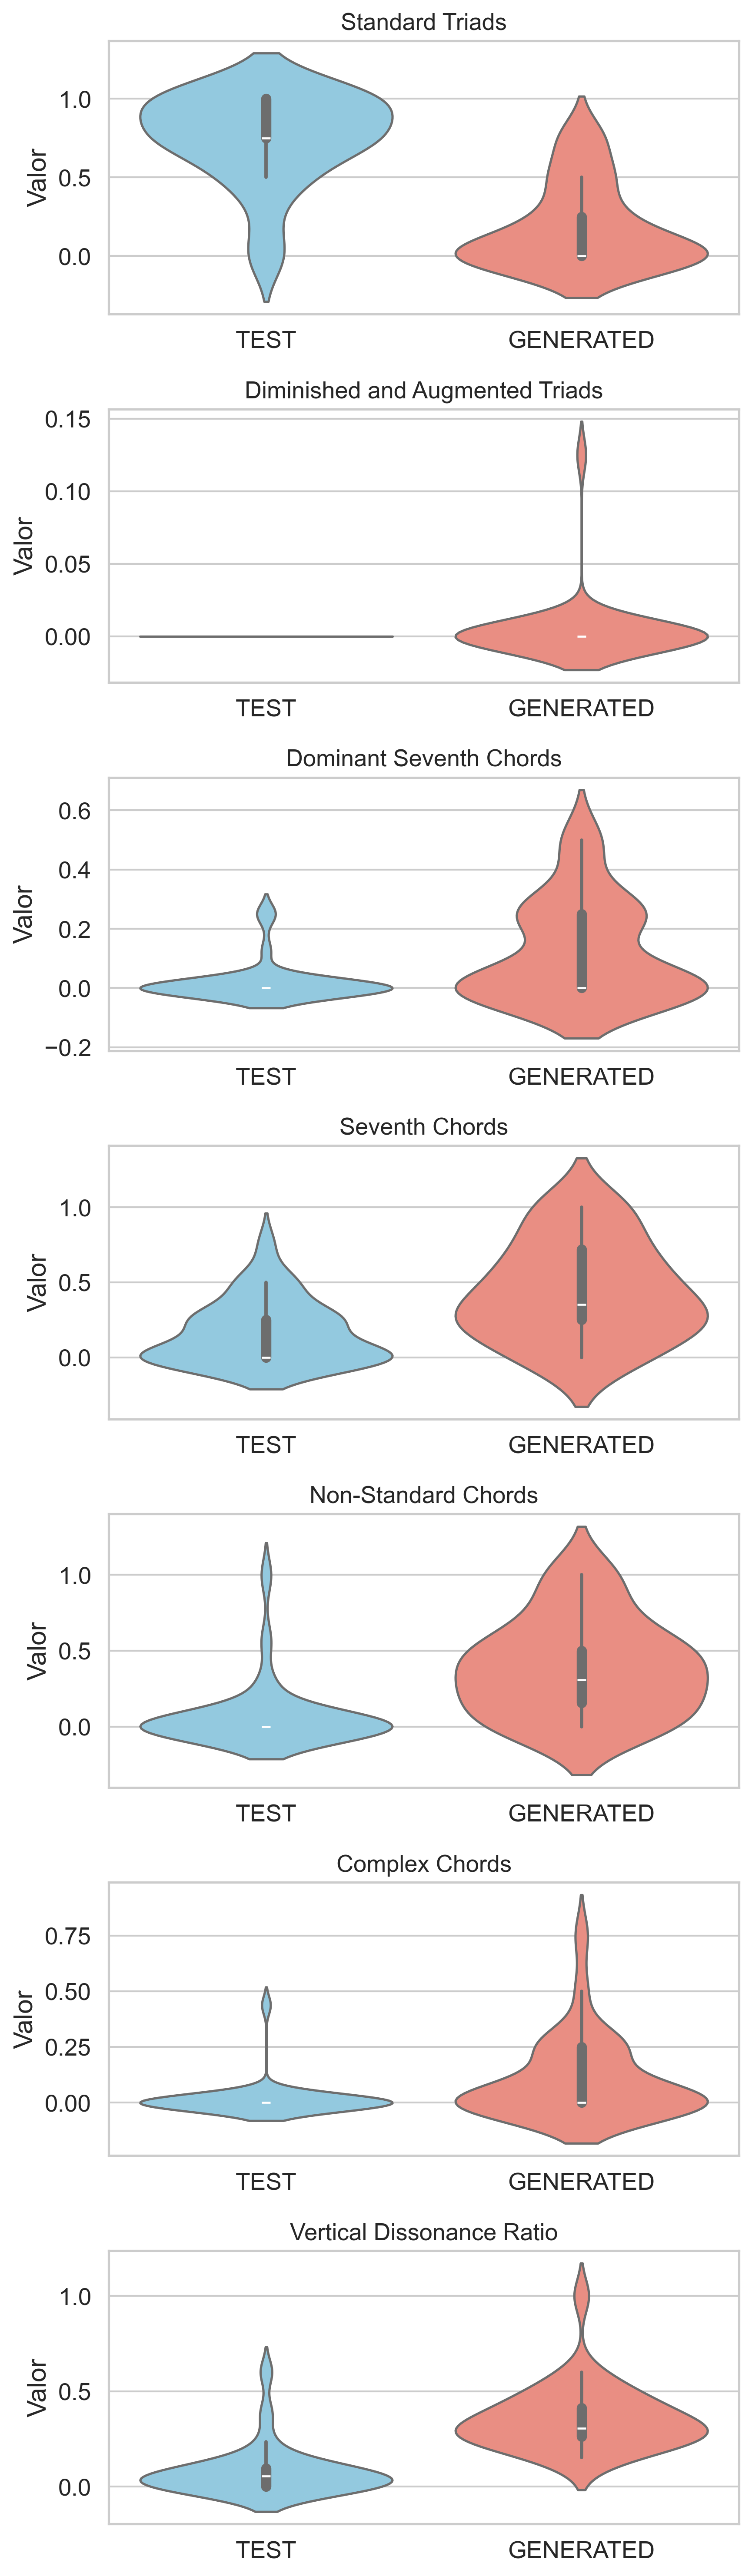

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Estilo general
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

# Lista de features en orden armónicamente lógico
features = [
    "Standard_Triads",
    "Diminished_and_Augmented_Triads",
    "Dominant_Seventh_Chords",
    "Seventh_Chords",
    "Non-Standard_Chords",
    "Complex_Chords",
    "Vertical_Dissonance_Ratio"
]

# Crear todos los violines en una figura vertical
fig, axes = plt.subplots(len(features), 1, figsize=(6, 20), dpi=300)

for i, feat in enumerate(features):
    sns.violinplot(x="set", y=feat, data=df, palette={"TEST": "skyblue", "GENERATED": "salmon"}, ax=axes[i])
    axes[i].set_title(feat.replace("_", " "), fontsize=13)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Valor")

plt.tight_layout()
plt.savefig("violin_plots_jSymbolic.png", dpi=200)
plt.show()
